imports

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.image import imread

import os
import tensorflow as tf
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras import layers, models
from tensorflow.keras.models import load_model

import the dataset

In [8]:
train_dir = 'train'
test_dir = 'test'


Encode dataset

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Creating training set
train = train_datagen.flow_from_directory(train_dir,
                                                 target_size = (224, 224),
                                                 batch_size = 16,
                                                 class_mode = 'categorical')
# Creating the Test set
test = test_datagen.flow_from_directory(test_dir,
                                            target_size = (224, 224),
                                            batch_size = 16,
                                            class_mode = 'categorical')

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


Visualize

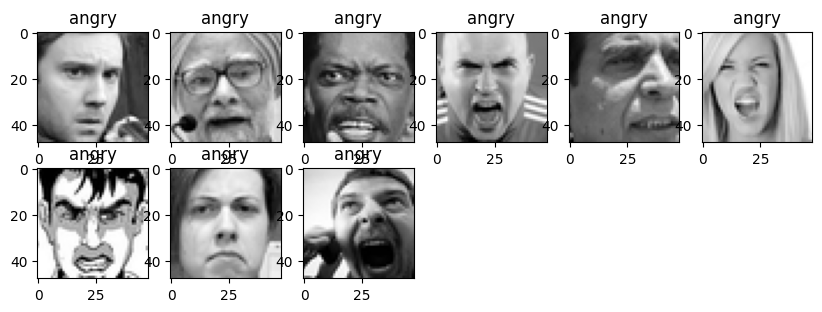

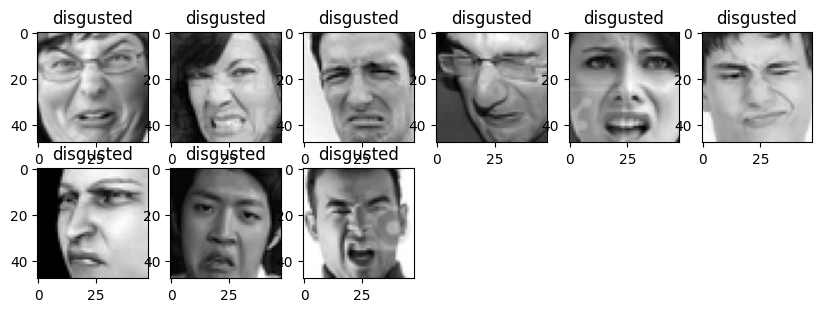

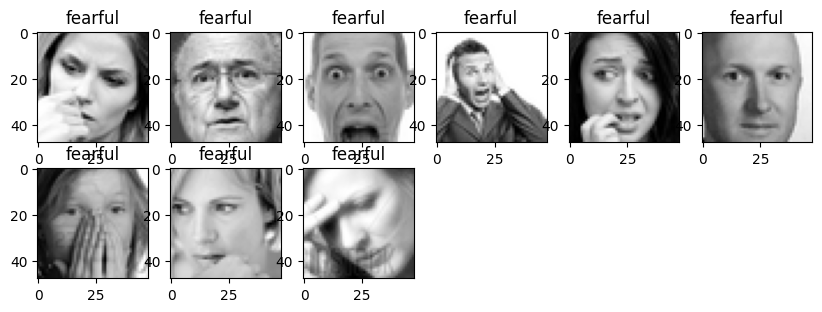

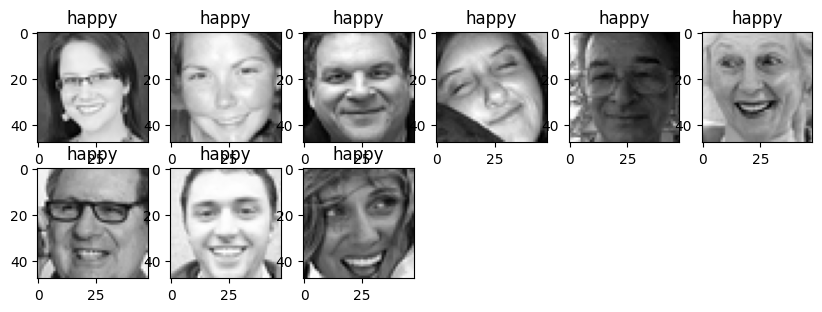

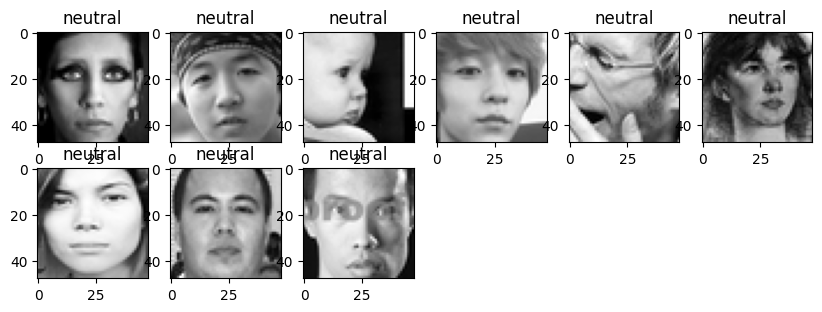

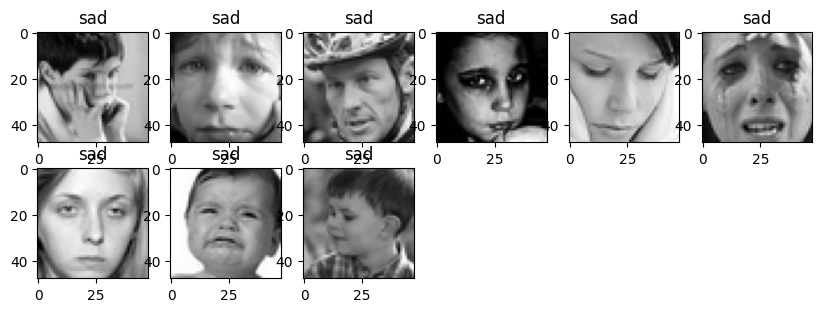

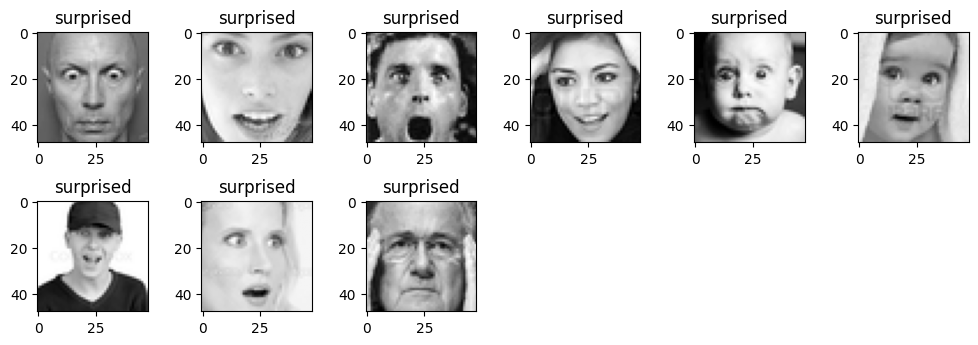

In [4]:
angry = 'train/angry/'
happy = 'train/happy/'
disgusted = 'train/disgusted/'
sad = 'train/sad/'
surprised = 'train/surprised/'
neutral = 'train/neutral/'
fearful = 'train/fearful/'


# plot first few images of angry
plt.figure(figsize=(10, 5))
for i in range(9):
	plt.subplot(3, 6, i + 1)
	filename = angry + 'im' + str(i) + '.png'
	image = imread(filename)
	plt.imshow(image, cmap='gray')
	plt.title("angry")


# plot first few images of disgusted
plt.figure(figsize=(10, 5))
for i in range(9):
	plt.subplot(3, 6, i + 1)
	filename = disgusted + 'im' + str(i) + '.png'
	image = imread(filename)
	plt.imshow(image, cmap='gray')
	plt.title("disgusted")
 
 # plot first few images of fearful
plt.figure(figsize=(10, 5))
for i in range(9):
	plt.subplot(3, 6, i + 1)
	filename = fearful + 'im' + str(i) + '.png'
	image = imread(filename)
	plt.imshow(image, cmap='gray')
	plt.title("fearful")
 
  # plot first few images of happy
plt.figure(figsize=(10, 5))
for i in range(9):
	plt.subplot(3, 6, i + 1)
	filename = happy + 'im' + str(i) + '.png'
	image = imread(filename)
	plt.imshow(image, cmap='gray')
	plt.title("happy")
 
   # plot first few images of neutral
plt.figure(figsize=(10, 5))
for i in range(9):
	plt.subplot(3, 6, i + 1)
	filename = neutral + 'im' + str(i) + '.png'
	image = imread(filename)
	plt.imshow(image, cmap='gray')
	plt.title("neutral")

   # plot first few images of sad
plt.figure(figsize=(10, 5))
for i in range(9):
	plt.subplot(3, 6, i + 1)
	filename = sad + 'im' + str(i) + '.png'
	image = imread(filename)
	plt.imshow(image, cmap='gray')
	plt.title("sad")

   # plot first few images of surprised
plt.figure(figsize=(10, 5))
for i in range(9):
	plt.subplot(3, 6, i + 1)
	filename = surprised + 'im' + str(i) + '.png'
	image = imread(filename)
	plt.imshow(image, cmap='gray')
	plt.title("surprised")

# show the figure
plt.tight_layout()
plt.show()

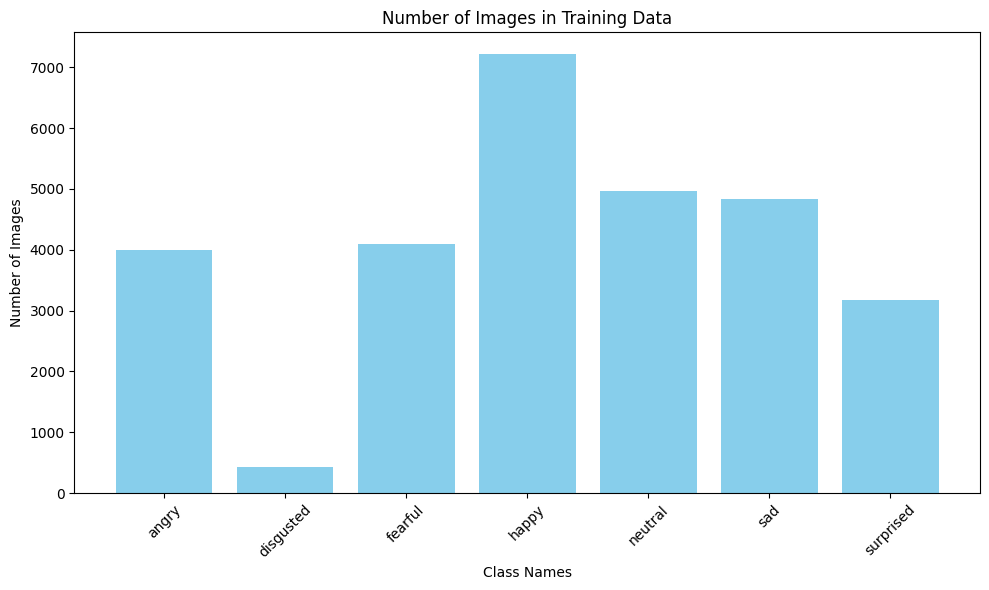

In [5]:
# Get class indices and their corresponding counts
class_counts = train.classes
class_labels = list(train.class_indices.keys())

# Count the number of images per class
counts = [list(class_counts).count(i) for i in range(len(class_labels))]

# Plot the graph
plt.figure(figsize=(10, 6))
plt.bar(class_labels, counts, color='skyblue')
plt.xlabel("Class Names")
plt.ylabel("Number of Images")
plt.title("Number of Images in Training Data")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Custom CNN

In [ ]:

num_classes = 7

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])


continue training if already trained

In [ ]:
"""from tensorflow.keras.models import load_model

model = load_model('emotion_detection.h5')"""

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, decay=1e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

In [32]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_52 (Conv2D)          (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_64 (Bat  (None, 224, 224, 32)     128       
 chNormalization)                                                
                                                                 
 conv2d_53 (Conv2D)          (None, 224, 224, 32)      9248      
                                                                 
 batch_normalization_65 (Bat  (None, 224, 224, 32)     128       
 chNormalization)                                                
                                                                 
 max_pooling2d_31 (MaxPoolin  (None, 112, 112, 32)     0         
 g2D)                                                            
                                                      

In [36]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
#early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

history = model.fit(
    train,
    steps_per_epoch=train.samples // train.batch_size,
    epochs=30,
    validation_data=test,
    validation_steps=test.samples // test.batch_size,
    callbacks=[reduce_lr]  
    
)

Epoch 1/30
1794/1794 [==============================] - 248s 138ms/step - loss: 1.0986 - accuracy: 0.5910 - val_loss: 1.1803 - val_accuracy: 0.5589 - lr: 1.0000e-04
Epoch 2/30
1794/1794 [==============================] - 253s 141ms/step - loss: 1.0808 - accuracy: 0.5940 - val_loss: 1.1173 - val_accuracy: 0.5753 - lr: 1.0000e-04
Epoch 3/30
1794/1794 [==============================] - 272s 152ms/step - loss: 1.0755 - accuracy: 0.5978 - val_loss: 1.1261 - val_accuracy: 0.5698 - lr: 1.0000e-04
Epoch 4/30
1794/1794 [==============================] - 498s 277ms/step - loss: 1.0635 - accuracy: 0.6027 - val_loss: 1.1680 - val_accuracy: 0.5647 - lr: 1.0000e-04
Epoch 5/30
1794/1794 [==============================] - 252s 140ms/step - loss: 1.0621 - accuracy: 0.6020 - val_loss: 1.0876 - val_accuracy: 0.5848 - lr: 1.0000e-04
Epoch 6/30
1794/1794 [==============================] - 254s 141ms/step - loss: 1.0557 - accuracy: 0.6050 - val_loss: 1.1079 - val_accuracy: 0.5783 - lr: 1.0000e-04
Epoch 7/30

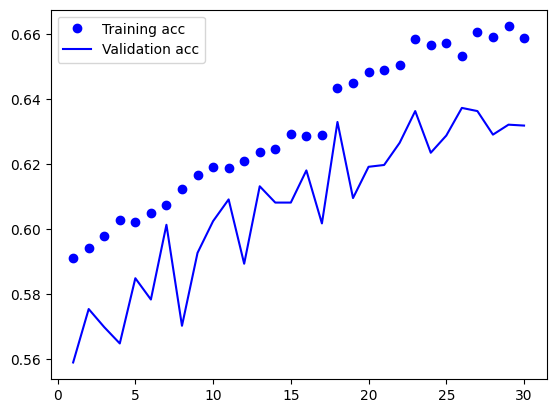

In [37]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1,len(acc)+1)
plt.plot(epochs,acc,'bo',label='Training acc')
plt.plot(epochs,val_acc,'b',label='Validation acc')
plt.legend()



plt.show()

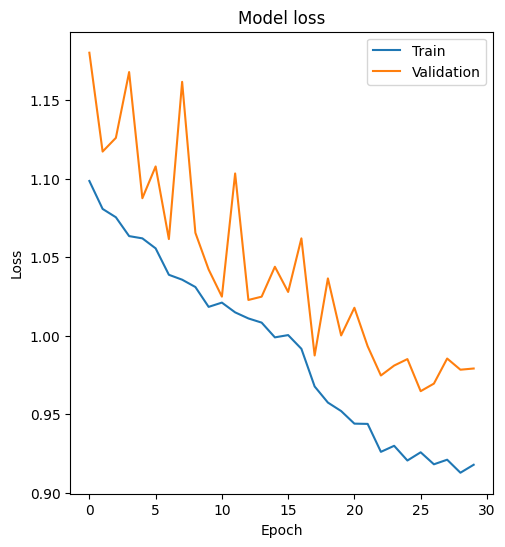

In [38]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.show()

In [39]:
test_loss, test_accuracy = model.evaluate(test, steps=test.samples // test.batch_size)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

448/448 [==============================] - 66s 146ms/step - loss: 0.9725 - accuracy: 0.6384
Test Loss: 0.9725
Test Accuracy: 0.6384


In [9]:
model.save('emotion_detection.h5')

1/1 [==============================] - 6s 6s/step


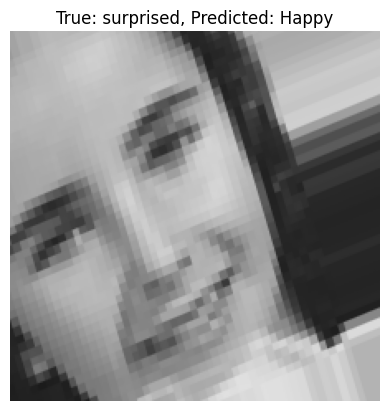

1/1 [==============================] - 0s 26ms/step


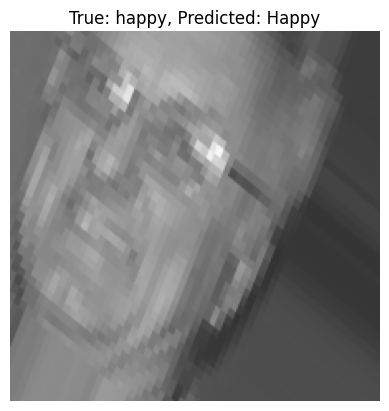

1/1 [==============================] - 0s 27ms/step


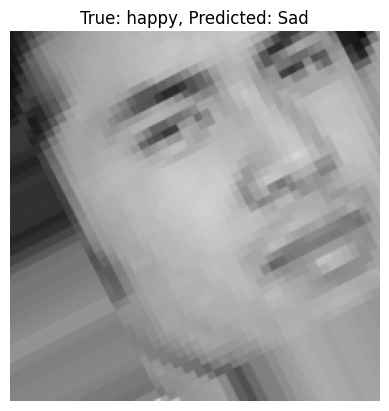

1/1 [==============================] - 0s 21ms/step


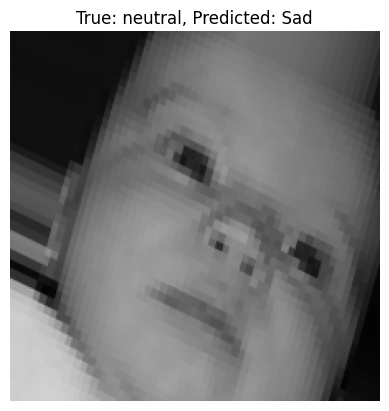

1/1 [==============================] - 0s 25ms/step


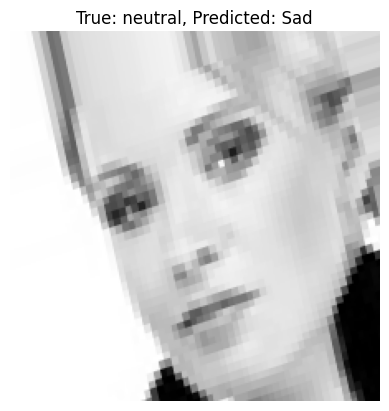

1/1 [==============================] - 0s 22ms/step


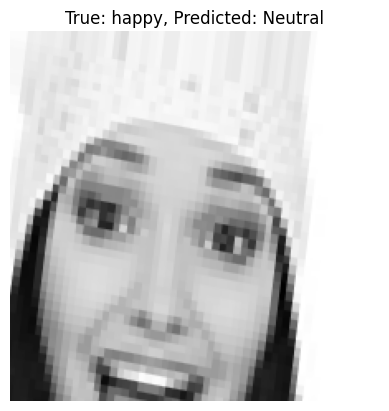

1/1 [==============================] - 0s 25ms/step


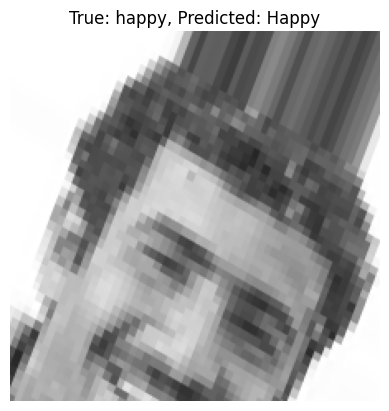

1/1 [==============================] - 0s 23ms/step


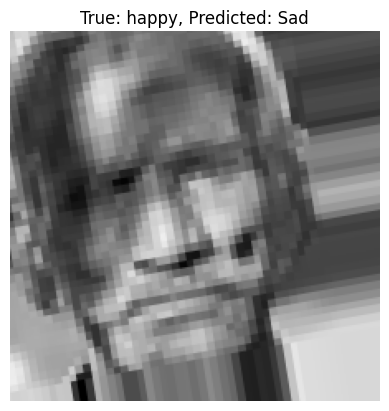

1/1 [==============================] - 0s 24ms/step


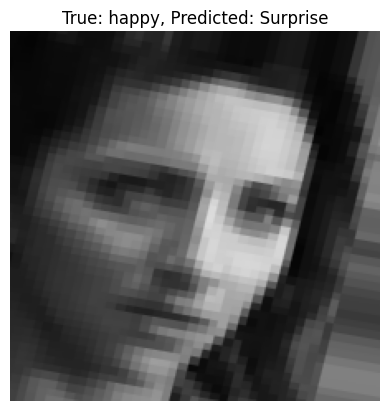

1/1 [==============================] - 0s 23ms/step


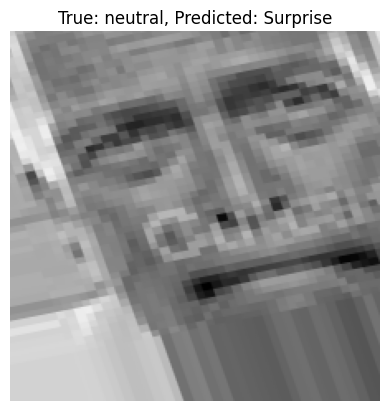

In [12]:
def get_random_images_from_generator(generator, num_images=10):
    # Get the class labels
    class_labels = list(generator.class_indices.keys())

    # Get a random selection of 10 images from the generator
    selected_images = []
    for _ in range(num_images):
        # Pick a random batch
        batch_index = random.choice(range(len(generator)))
        batch_images, batch_labels = generator[batch_index]

        # Pick a random image from this batch
        image = batch_images[random.choice(range(len(batch_images)))]
        image_label = batch_labels[random.choice(range(len(batch_labels)))]
        
        # Map the label to emotion
        true_emotion = class_labels[np.argmax(image_label)]
        selected_images.append((image, true_emotion))
    
    return selected_images

# Get 10 random images from the test set
random_images = get_random_images_from_generator(test, 10)

# Display the selected images and make predictions
for img_array, true_emotion in random_images:
    # Make a prediction using the pre-trained model
    emotion_probabilities = model.predict(np.expand_dims(img_array, axis=0))  # Add batch dimension
    predicted_emotion_index = np.argmax(emotion_probabilities[0])  # Get the index of the highest probability
    predicted_emotion = emotion_labels[predicted_emotion_index]  # Get the label of the predicted emotion

    # Display the image with the true emotion and predicted emotion
    plt.imshow(img_array)
    plt.title(f"True: {true_emotion}, Predicted: {predicted_emotion}")
    plt.axis('off')
    plt.show()

In [ ]:
"""model = tf.keras.models.load_model('emotion_detection.h5')
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Initialize OpenCV camera
cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        # Add margin
        margin = 10
        x1 = max(0, x - margin)
        y1 = max(0, y - margin)
        x2 = min(frame.shape[1], x + w + margin)
        y2 = min(frame.shape[0], y + h + margin)

        roi = frame[y1:y2, x1:x2]
        roi = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)  
        roi = cv2.resize(roi, (224, 224))
        roi = roi.astype('float32') / 255.0         
        roi = np.expand_dims(roi, axis=0)

        prediction = model.predict(roi)[0]
        print("Prediction vector:", prediction)    

        emotion_idx = np.argmax(prediction)
        emotion = emotion_labels[emotion_idx]
        confidence = np.max(prediction)

        
        if confidence > 0.6:
            label = f"{emotion}"
        else:
            label = "Uncertain"

        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(frame, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (36, 255, 12), 2)

    cv2.imshow('Emotion Detector', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()"""

1/1 [==============================] - 7s 7s/step
Prediction vector: [2.7214849e-02 1.5319751e-04 1.1122313e-01 9.4120435e-02 4.7484639e-01
 5.3888474e-02 2.3855351e-01]
1/1 [==============================] - 0s 88ms/step
Prediction vector: [6.8424597e-02 3.9140179e-04 9.8742731e-02 1.1020599e-02 3.3899254e-01
 4.6344611e-01 1.8981997e-02]
1/1 [==============================] - 0s 28ms/step
Prediction vector: [7.0839517e-02 3.3841658e-04 1.0034423e-01 1.2756930e-02 3.2390231e-01
 4.7048408e-01 2.1334480e-02]
1/1 [==============================] - 0s 22ms/step
Prediction vector: [8.1741795e-02 3.6135936e-04 1.1066130e-01 1.8123770e-02 2.7961043e-01
 4.8120704e-01 2.8294355e-02]
1/1 [==============================] - 0s 28ms/step
Prediction vector: [8.4789075e-02 2.3718063e-04 7.9667732e-02 1.7683273e-02 4.5689696e-01
 3.3712283e-01 2.3602987e-02]
1/1 [==============================] - 0s 25ms/step
Prediction vector: [0.08789577 0.00042723 0.09489605 0.02724088 0.3758924  0.38153413
 0.0

KeyboardInterrupt: 